# Loading trained model.

## Prepare the notebook.

### Importing the libraries.

In [1]:
import os
import sys

from anndata import AnnData
import hydra
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from tqdm import tqdm
import wandb

from sc_exp_design import constants 
from sc_exp_design.data.container import DataMixin
from sc_exp_design.training.callbacks import MetricsCallBack
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../../../../scripts")
from data_utils import annotate_perturbations, apply_shared_transformations, get_protocol_tranformations
from ood_utils import split_adata
from validation_utils import predict_on_ood_data

### Constants.

In [2]:
TEAM = "inverse-perturbation-models"
PROJECT = "haematopoiesis_forward_model_protocol_concat_X_pca+X_scatter_standardized"

## Load runs.

### Prepare API and load runs.

In [8]:
api = wandb.Api()
runs = api.runs(f"{TEAM}/{PROJECT}")
len(runs)

6

### Retrieving shared configurations.

In [9]:
first_config = runs[-1].config
first_config = OmegaConf.create(first_config)
OmegaConf.resolve(first_config)

## Data.

### Reading data into memory.

In [ ]:
h5ad_path = first_config["paths"]["h5ad_path"]
adata = sc.read_h5ad(h5ad_path)
adata

### Annotating perturbations.

In [ ]:
column2tranform = get_protocol_tranformations(
    first_config.annotation.protocol_columns,
    log1p_exp_cols=first_config.annotation.log1p_exp_cols,
    log21p_exp_cols=first_config.annotation.log21p_exp_cols,
)
adata = annotate_perturbations(
    adata,
    first_config.annotation.protocol_columns,
    protocol_obs_key_added=first_config.annotation.protocol_obs_key_added,
    protocol_sep=first_config.annotation.protocol_sep,
    one_hot_uns_key_added=first_config.annotation.one_hot_uns_key_added,
    column2tranform=column2tranform,
    protocol_obsm_key=first_config.annotation.protocol_obsm_key,
)
adata

AnnData object with n_obs × n_vars = 93275454 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[

## Models.

### Prepare utility functions for loading the model.

In [ ]:
def init_and_resolve_omegaconf(
    config_dict,
):
    cfg = OmegaConf.create(config_dict)
    OmegaConf.resolve(cfg)
    return cfg

def load_model_from_run(
    run_name,
    config
):
    dump_dir = config.paths.dump_dir
    dump_path = os.path.join(dump_dir, f"{run_name}_FlowMatching.pkl")
    return FlowMatching.load(dump_path)

def get_ood_splits_and_compute_shared_transformations(
    adata,
    config
):
    train_adata, ood_adatas_dict = split_adata(
        adata,
        config.ood.obs_column,
        config.ood.unique_value_ids,
    )
    train_adata, ood_adatas_dict = apply_shared_transformations(
        train_adata,
        ood_adatas_dict,
        config.transforms.scatter_columns,
        compute_channel_pcs=config.transforms.compute_channel_pcs,
    )
    return train_adata, ood_adatas_dict

### Defining OOD Split and retrieve the respective runs.

In [ ]:
ood_obs_column = "days_of_culture"
ood_unique_val = 5
ood_runs = [
    run for run in runs if run.config["ood"]["obs_column"] == ood_obs_column and
        run.config["ood"]["unique_value_ids"] == ood_unique_val
]
print(len(ood_runs))
run = ood_runs[0]


1


### Loading run.

In [ ]:
# resolving config
config = init_and_resolve_omegaconf(run.config)
# loading model
print(f"Loading model for run {run.name}")
flow_matching = load_model_from_run(run.name, config)

Loading model for run earnest-sponge-1


### Retrieving splits.

In [ ]:
print(f"Splitting data for {run.name}")
train_adata, ood_adatas_dict = get_ood_splits_and_compute_shared_transformations(adata, config)
train_adata, ood_adatas_dict

Splitting data for earnest-sponge-1


(AnnData object with n_obs × n_vars = 92293092 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 's

### Predicting for each unseen combination.

In [ ]:
num_time_steps = 100
solver_kwargs = {"method": "euler"}
N = 10_000
results_dict = {}

ood_adata = ood_adatas_dict[ood_unique_val]
ood_adata.obsm["X_pca"] = np.einsum("...d,dk -> ...k", ood_adata.X, train_adata.varm["PCs"])
ood_data = flow_matching.data_manager.get_data(ood_adata)


perturbation_data = ood_data.perturbation_data
perturbation_data = DataMixin(ood_data.perturbation_data)
unique_perts = perturbation_data.apply(lambda x: np.unique(x, axis=0))

# iterating over unique perturbations
results_dict = {}
for idx in tqdm(range(next(iter(unique_perts.values())).shape[0])):
    # retrieving mask for current combination
    comb_perts = unique_perts.apply(lambda x: x[idx, :])
    comb_idxs = np.where(np.all(next(iter(perturbation_data.values())) == next(iter(comb_perts.values())), axis=-1))[0]

    # slicing the array and predicting
    comb_adata = ood_adata[comb_idxs, :]
    comb_data = flow_matching.data_manager.get_data(comb_adata)
    # comb_data = ood_data[comb_idxs]
    comb_perts = comb_perts.apply(lambda x: torch.from_numpy(x[None]).float().to(flow_matching.device).repeat(N, 1))
    preds = flow_matching.predict(
        {
            constants.DataFields.PERTURBATION_DATA: comb_perts,
        },
        num_time_steps=num_time_steps,
        solver_kwargs=solver_kwargs,
    ).detach().cpu().numpy()

    # storing the results
    results_dict[idx] = {
        constants.PredictionFields.PREDICTION_DATA: preds,
        constants.DataFields.TARGET_STATE: comb_data.state_data
    }

100%|██████████| 2/2 [00:06<00:00,  3.33s/it]


### Predicting for each seen combination.

In [ ]:
# num_time_steps = 100
# solver_kwargs = {"method": "euler"}
# N = 10_000
# results_dict = {}
# for comb in ood_data.seen_combinations:
#     comb_mask = np.all((ood_data.adata.obs.loc[:, flow_matching.data_manager.perturbations] == comb).values, axis=-1)
#     if not np.any(comb_mask):
#         # logger.warning(f"No cells found for combination {comb}, skipping.")
#         continue
#     comb_data = flow_matching.data_manager.get_data(ood_adata[np.where(comb_mask)[0]])

#     # generating samples
#     comb_perts = DataMixin(comb_data.perturbation_data)
#     comb_perts = comb_perts.apply(lambda x: np.unique(x, axis=0))
#     comb_perts = comb_perts.apply(lambda x: torch.from_numpy(x).float().to(flow_matching.device).repeat(N, 1))
#     preds = flow_matching.predict(
#         {
#             constants.DataFields.PERTURBATION_DATA: comb_perts,
#         },
#         num_time_steps=num_time_steps,
#         solver_kwargs=solver_kwargs,
#     ).detach().cpu().numpy()

#     # storing results
#     results_dict[comb] = {
#         constants.PredictionFields.PREDICTION_DATA: preds,
#         constants.DataFields.TARGET_STATE: comb_data.state_data
#     }


### Subsampling target states.

In [ ]:
subsampled_results = {}
K = 10000
SEED = 42
for group, group_data in results_dict.items():
    np.random.seed(SEED)
    idxs = np.random.choice(group_data["target"].shape[0], (K))
    subsampled_results[group] = {
        "predicted_states": group_data["predicted_states"],
        "target": group_data["target"][idxs],
    }

### Prepare and compute metrics.

In [ ]:
metrics_callback = MetricsCallBack(
    ["r_squared", "energy_distance", ],
    state_transforms=None,
)
metrics_dict = metrics_callback.run_on_valid_step(subsampled_results)
metrics_dict

{'0_r_squared': -70.81455993652344,
 '0_energy_distance': np.float64(8.470330475621552),
 '1_r_squared': -236.29891967773438,
 '1_energy_distance': np.float64(9.291614330270729)}

### Computing channel mean.

There was a bug in the code, we need to recompute them.

In [ ]:
X_channel = train_adata.X
channel_mean = X_channel.mean(0)
channel_std = X_channel.std(0)

### Plotting marginals.

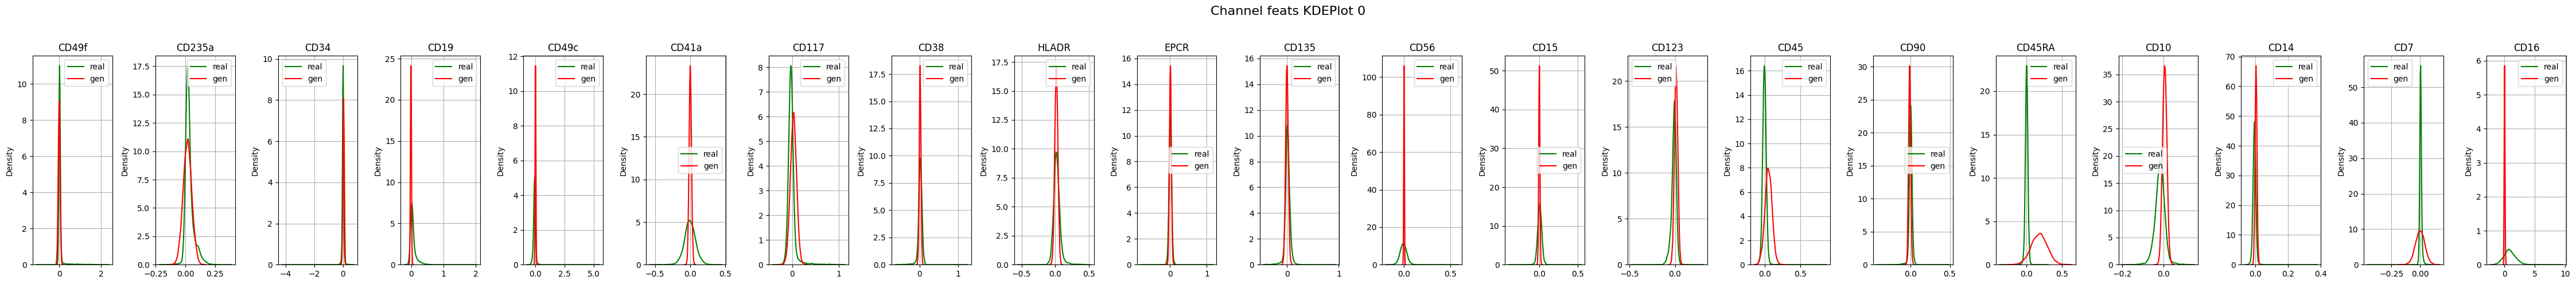

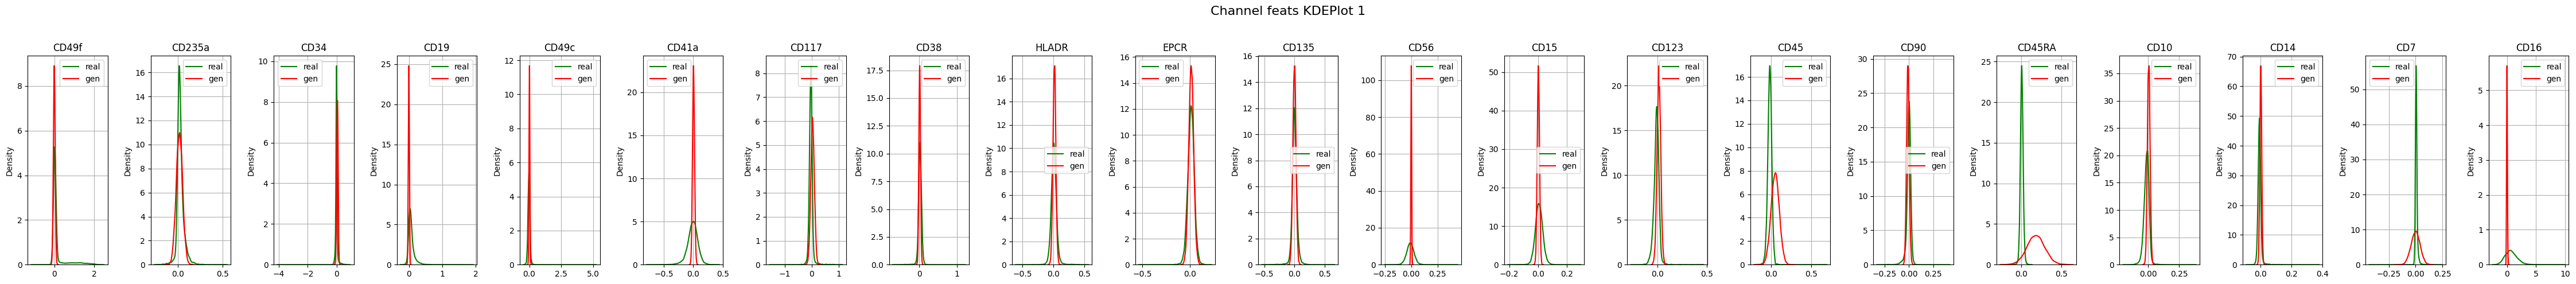

In [ ]:
def plot_marginals(X_real, X_gen=None, col_names=None, title=""):
   
    # sanity checks
    n_channels = X_real.shape[1]
    if X_gen is not None:
        assert X_gen.shape[1] == n_channels
    if col_names is not None:
        assert len(col_names) == n_channels

    # create subplots (1 row, n_channels columns)
    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"{title}", fontsize=16)

    # loop over channels
    for i in range(n_channels):
        ax[i].grid(True)
        sns.kdeplot(X_real[:, i], ax=ax[i], color="green", label="real")
        if X_gen is not None:
            sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="gen")
        ax[i].legend()
        if col_names is not None:
            ax[i].set_title(col_names[i])

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    # fig.show()
    return fig

for k, v in subsampled_results.items():
    predicted_states = v["predicted_states"]
    target = v["target"]

    x_gen_channel =  predicted_states[:, :21]
    x_true_channel =  target[:, :21]
    # rescaling the data
    # x_true_channel = (x_true_channel - channel_mean)/channel_std
    x_gen_channel = channel_mean + x_gen_channel*channel_std
    plot_marginals(x_true_channel, X_gen=x_gen_channel, col_names=adata.var_names, title=f"Channel feats KDEPlot {k}")

    # x_gen_scatter =  predicted_states[:, 21:]
    # x_true_scatter =  target[:, 21:]
    # plot_marginals(x_true_scatter, X_gen=x_gen_scatter, col_names=config["annotation"]["scatter_columns"], title=f"Scatter feats KDEPlot {k}")


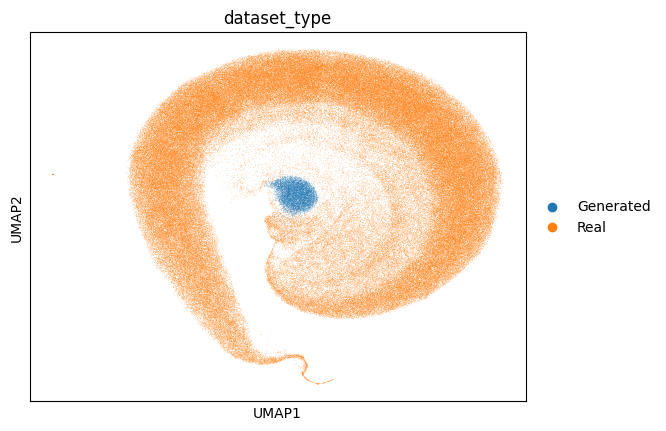

In [ ]:
def get_generated_adata(
    x_true, x_gen,
    n_channel_feats=21, is_pca=True, **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(x_true.shape[0])] + ["Generated" for _ in range(x_gen.shape[0])], **kwargs}
    obsm = {}
    if x_true.shape[-1]>n_channel_feats:
        x_true_scatter = x_true[:, n_channel_feats:]
        x_true = x_true[:, :n_channel_feats]

        x_gen_scatter = x_gen[:, n_channel_feats:]
        x_gen = x_gen[:, :n_channel_feats]
        obsm["X_scatter"] = np.concatenate((x_true_scatter, x_gen_scatter), axis=0)
    if is_pca:
        obsm["X_pca"] = np.concatenate((x_true, x_gen), axis=0)
    adata_generated = sc.AnnData(X=np.concatenate([x_true, x_gen], axis=0), obs=obs, obsm=obsm)

    if not is_pca:
        sc.pp.pca(adata_generated)
    sc.pp.neighbors(adata_generated, n_neighbors=15)
    sc.tl.umap(adata_generated)
    return adata_generated

group2adata = {}

for k, v in subsampled_results.items():
    predicted_states = v["predicted_states"]
    target = results_dict[k]["target"].toarray()

    # x_gen_channel =  predicted_states[:, :21]
    # x_true_channel =  target[:, :21]
    # rescaling the data
    # x_true_channel = (x_true_channel - channel_mean)/channel_std
    # x_gen_channel = channel_mean + x_gen_channel*channel_std
    # predicted_states[:, :21] = x_gen_channel

    # target[:, :21] = x_true_channel
    group2adata[k] = get_generated_adata(target, predicted_states)
    sc.pl.embedding(group2adata[k], "umap", color=group2adata[k].obs.columns)
